[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/pilot/ch03_workbook.ipynb)

# Classical language models

An n-gram model predicts a word from the n − 1 words before it, with
P(w | h) = count(h w) / count(h) counted in a training text. Every n-gram the
training text lacks gets probability zero, and one zero sets the probability
of the whole test text to zero. Smoothing moves probability from seen
n-grams to unseen ones. The models train on the first chapters of Pride and
Prejudice and are tested on its last chapters.

In [1]:
import math
import os
import re
import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

MIRROR_REF = "pilot"
TEXT_URL = f"https://raw.githubusercontent.com/josterri/predicting-the-next-words-notebooks/{MIRROR_REF}/data/pride_and_prejudice.txt"


def load_novel():
    """Pride and Prejudice as lowercase word tokens, one list per chapter."""
    if os.environ.get("PNW_TEXT"):
        text = open(os.environ["PNW_TEXT"], encoding="utf-8").read()
    else:
        text = urllib.request.urlopen(TEXT_URL).read().decode("utf-8")
    chapters = re.split(r"(?m)^CHAPTER [IVXLC]+\.$", text)[1:]
    return [re.findall(r"[a-z]+(?:'[a-z]+)*", c.lower().replace("’", "'")) for c in chapters]


chapters = load_novel()
n_train = round(0.9 * len(chapters))
train_chapters, test_chapters = chapters[:n_train], chapters[n_train:]
display(Markdown(f"{len(chapters)} chapters: the first {n_train} train the models, the last "
                 f"{len(test_chapters)} test them."))

61 chapters: the first 55 train the models, the last 6 test them.

## Smoothing decides how much mass the unseen get and never which of them deserve it

Add-k adds k to the count of every n-gram, seen or unseen:
P(w | h) = (count(h w) + k) / (count(h) + k·V), where V is the number of word
types. A history the training text never contains gives every type the same
probability 1 / V. Held-out perplexity on the last chapters, for three values
of k and orders n = 1 to 4:

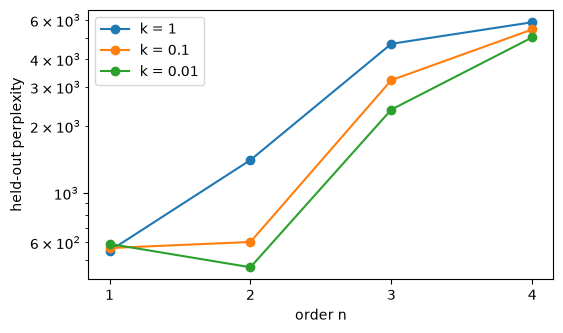

With k = 1, perplexity is lowest at n = 1 (549) and reaches 5,870 at n = 4. With k = 0.1, perplexity is lowest at n = 1 (566) and reaches 5,448 at n = 4. With k = 0.01, perplexity is lowest at n = 2 (464) and reaches 5,019 at n = 4.

In [2]:
N_MAX = 4
START = N_MAX - 1


def prepare(train_chapters, test_chapters):
    """Training tokens, test tokens with unknown words as <unk>, and V."""
    train = [w for c in train_chapters for w in c]
    vocab = set(train) | {"<unk>"}
    test = [w if w in vocab else "<unk>" for c in test_chapters for w in c]
    return train, test, len(vocab)


def ngram_counts(tokens, n_max):
    """counts[n][g] is how often the n-gram g occurs; counts[0][()] is the token count."""
    counts = {0: Counter({(): len(tokens)})}
    for n in range(1, n_max + 1):
        counts[n] = Counter(tuple(tokens[i - n + 1:i + 1]) for i in range(n - 1, len(tokens)))
    return counts


def perplexity(counts, test, V, n, k):
    """Add-k perplexity of the order-n model on the test tokens; inf once a token gets probability 0."""
    log_sum = 0.0
    for i in range(START, len(test)):
        g = tuple(test[i - n + 1:i + 1])
        den = counts[n - 1][g[:-1]] + k * V
        p = (counts[n][g] + k) / den if den else 0.0
        if p == 0:
            return math.inf
        log_sum += math.log(p)
    return math.exp(-log_sum / (len(test) - START))


train, test, V = prepare(train_chapters, test_chapters)
counts = ngram_counts(train, N_MAX)
orders = list(range(1, N_MAX + 1))
pp = {k: [perplexity(counts, test, V, n, k) for n in orders] for k in (1, 0.1, 0.01)}
fig, ax = plt.subplots(figsize=(6, 3.5))
for k, row in pp.items():
    ax.plot(orders, row, marker="o", label=f"k = {k}")
ax.set(xlabel="order n", ylabel="held-out perplexity", xticks=orders, yscale="log")
ax.legend()
plt.show()
display(Markdown(" ".join(
    f"With k = {k}, perplexity is lowest at n = {orders[int(np.argmin(row))]} ({min(row):,.0f}) "
    f"and reaches {row[-1]:,.0f} at n = {N_MAX}." for k, row in pp.items())))

## Zeros are the default state of the table

A test n-gram that never occurs in the training chapters has count zero. The
longer the n-gram, the larger the share of test n-grams with count zero:

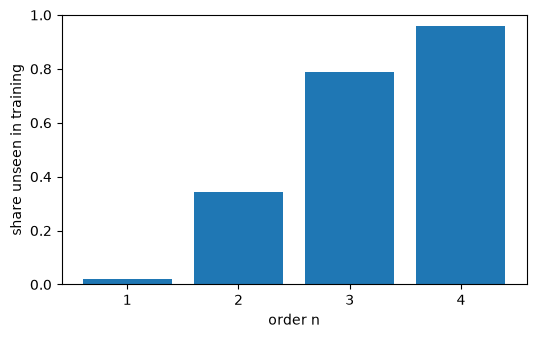

Unseen in training: 1.9% of test 1-grams, 34.3% of test 2-grams, 78.9% of test 3-grams, 95.8% of test 4-grams.

In [3]:
def unseen_share(counts, test, n):
    """Share of the scored test positions whose n-gram never occurs in training."""
    return sum(counts[n][tuple(test[i - n + 1:i + 1])] == 0 for i in range(START, len(test))) / (len(test) - START)


shares = [unseen_share(counts, test, n) for n in orders]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(orders, shares)
ax.set(xlabel="order n", ylabel="share unseen in training", xticks=orders, ylim=(0, 1))
plt.show()
display(Markdown("Unseen in training: " + ", ".join(
    f"{s:.1%} of test {n}-grams" for n, s in zip(orders, shares)) + "."))

## Exercise 1. The smoothing constant k

Set `K` to 1, 0.1, 0.01 and 0.001 in turn, and rerun the cell each time.
Then set `K = 0`. At which k is each order best, and what does `K = 0` do to
the perplexity?

In [4]:
K = 0.01

for n in (2, 4):
    print(f"n = {n}, k = {K}: perplexity {perplexity(counts, test, V, n, K):,.0f}")

n = 2, k = 0.01: perplexity 464
n = 4, k = 0.01: perplexity 5,019


### Solution

In [5]:
ks = [1, 0.3, 0.1, 0.03, 0.01, 0.003, 0.001]
table = {n: [perplexity(counts, test, V, n, k) for k in ks] for n in (2, 4)}
for n in (2, 4):
    print(f"n = {n}: " + "  ".join(f"k={k}: {p:,.0f}" for k, p in zip(ks, table[n])))
zeros = sum(counts[2][tuple(test[i - 1:i + 1])] == 0 for i in range(START, len(test)))
c, d = counts[1][("mr",)], sum(1 for g in counts[2] if g[0] == "mr")
share = {k: (V - d) * k / (c + k * V) for k in (1, 0.01)}
display(Markdown(
    f"Over k = {', '.join(map(str, ks))}, the bigram is best at k = {ks[int(np.argmin(table[2]))]} ({min(table[2]):,.0f}) and the 4-gram at "
    f"k = {ks[int(np.argmin(table[4]))]} "
    f"({min(table[4]):,.0f}). After \"mr\", seen {c:,} times and followed by {d} different words, "
    f"add-k gives the words it was never followed by {share[1]:.0%} of the mass at k = 1 and "
    f"{share[0.01]:.0%} at k = 0.01. "
    f"At k = 0, {zeros:,} test bigrams have probability zero, and the first of them makes the "
    f"perplexity infinite."))

n = 2: k=1: 1,409  k=0.3: 857  k=0.1: 603  k=0.03: 485  k=0.01: 464  k=0.003: 512  k=0.001: 623
n = 4: k=1: 5,870  k=0.3: 5,667  k=0.1: 5,448  k=0.03: 5,209  k=0.01: 5,019  k=0.003: 4,888  k=0.001: 4,905


Over k = 1, 0.3, 0.1, 0.03, 0.01, 0.003, 0.001, the bigram is best at k = 0.01 (464) and the 4-gram at k = 0.003 (4,888). After "mr", seen 732 times and followed by 25 different words, add-k gives the words it was never followed by 89% of the mass at k = 1 and 8% at k = 0.01. At k = 0, 4,160 test bigrams have probability zero, and the first of them makes the perplexity infinite.

## Exercise 2. The order n and unseen histories

Set `N` to 1, 2, 3 and 4 in turn. At how many test positions has the history,
the n − 1 words before the word, never occurred in training, and what
probability does add-k give the word at such a position?

In [6]:
N = 3

unseen = sum(counts[N - 1][tuple(test[i - N + 1:i])] == 0 for i in range(START, len(test)))
print(f"n = {N}: {unseen:,} of {len(test) - START:,} histories unseen; "
      f"perplexity at k = 0.01: {perplexity(counts, test, V, N, 0.01):,.0f}")

n = 3: 4,160 of 12,141 histories unseen; perplexity at k = 0.01: 2,375


### Solution

In [7]:
rows = []
for n in orders:
    unseen = sum(counts[n - 1][tuple(test[i - n + 1:i])] == 0 for i in range(START, len(test)))
    rows.append(unseen / (len(test) - START))
    print(f"n = {n}: {unseen:,} of {len(test) - START:,} histories unseen ({rows[-1]:.1%})")
display(Markdown(
    f"The share of unseen histories grows from {rows[0]:.0%} at n = 1 to {rows[-1]:.0%} at n = {N_MAX}. "
    f"After an unseen history add-k with any k > 0 gives the next word (0 + k) / (0 + k·V) = 1 / {V:,}, "
    f"so each such position contributes as much as a uniform guess over all {V:,} types."))

n = 1: 0 of 12,141 histories unseen (0.0%)
n = 2: 232 of 12,141 histories unseen (1.9%)
n = 3: 4,160 of 12,141 histories unseen (34.3%)
n = 4: 9,578 of 12,141 histories unseen (78.9%)


The share of unseen histories grows from 0% at n = 1 to 79% at n = 4. After an unseen history add-k with any k > 0 gives the next word (0 + k) / (0 + k·V) = 1 / 6,103, so each such position contributes as much as a uniform guess over all 6,103 types.

## Exercise 3. Interpolation weights

Interpolation mixes three models: P = λ1·P1 + λ2·P2 + λ3·P3, with an add-one
unigram P1 and unsmoothed bigram and trigram estimates P2 and P3. Try
`LAMBDAS` = (1, 0, 0), (0.3, 0.7, 0), (0.1, 0.3, 0.6) and (0, 0, 1). Which
weights give the lowest perplexity, and what happens at (0, 0, 1)?

In [8]:
LAMBDAS = (0.2, 0.5, 0.3)


def interpolated(counts, test, V, lambdas):
    """Perplexity of the interpolated unigram, bigram and trigram on the test tokens."""
    assert abs(sum(lambdas) - 1) < 1e-9, "the weights must sum to 1"
    log_sum = 0.0
    for i in range(START, len(test)):
        p = lambdas[0] * (counts[1][(test[i],)] + 1) / (counts[0][()] + V)
        for n in (2, 3):
            g = tuple(test[i - n + 1:i + 1])
            if counts[n - 1][g[:-1]]:
                p += lambdas[n - 1] * counts[n][g] / counts[n - 1][g[:-1]]
        if p == 0:
            return math.inf
        log_sum += math.log(p)
    return math.exp(-log_sum / (len(test) - START))


print(f"weights {LAMBDAS}: perplexity {interpolated(counts, test, V, LAMBDAS):,.0f}")

weights (0.2, 0.5, 0.3): perplexity 306


### Solution

In [9]:
tries = [(1, 0, 0), (0, 1, 0), (0, 0, 1), (0.3, 0.7, 0), (0.2, 0.5, 0.3), (0.1, 0.3, 0.6)]
res = {lam: interpolated(counts, test, V, lam) for lam in tries}
for lam, p in res.items():
    print(f"{lam}: {p:,.0f}")
best = min(res, key=res.get)
addk = min(min(row) for row in pp.values())
display(Markdown(
    f"Of these weights, {best} gives the lowest perplexity, {res[best]:,.0f}, "
    f"{'below' if res[best] < addk else 'above'} the best add-k perplexity, {addk:,.0f}. "
    f"The unigram keeps every word above zero; the bigram and trigram add weight where their history "
    f"was seen. With (0, 0, 1), a trigram unseen in training has probability zero and the perplexity "
    f"is {'infinite' if math.isinf(res[(0, 0, 1)]) else format(res[(0, 0, 1)], ',.0f')}."))

(1, 0, 0): 549
(0, 1, 0): inf
(0, 0, 1): inf
(0.3, 0.7, 0): 273
(0.2, 0.5, 0.3): 306
(0.1, 0.3, 0.6): 458


Of these weights, (0.3, 0.7, 0) gives the lowest perplexity, 273, below the best add-k perplexity, 464. The unigram keeps every word above zero; the bigram and trigram add weight where their history was seen. With (0, 0, 1), a trigram unseen in training has probability zero and the perplexity is infinite.

## Exercise 4. The size of the training text

`TRAIN_SHARE` is the share of the training chapters the bigram model counts,
starting from chapter 1. Set it to 0.1, 0.25, 0.5 and 1. How do V, the share of
test bigrams unseen in training and the perplexity move, and why does the
test text change with V?

In [10]:
TRAIN_SHARE = 0.25

part = train_chapters[:max(1, round(TRAIN_SHARE * len(train_chapters)))]
tr, te, v = prepare(part, test_chapters)
c2 = ngram_counts(tr, 2)
print(f"{len(part)} of {len(train_chapters)} training chapters, {len(tr):,} tokens, V = {v:,}, <unk> in test: {te.count('<unk>'):,}, "
      f"unseen bigrams: {unseen_share(c2, te, 2):.0%}, perplexity: {perplexity(c2, te, v, 2, 0.01):,.0f}")

14 of 55 training chapters, 20,737 tokens, V = 2,751, <unk> in test: 1,029, unseen bigrams: 56%, perplexity: 751


### Solution

In [11]:
out = []
for share in (0.1, 0.25, 0.5, 1):
    part = train_chapters[:max(1, round(share * len(train_chapters)))]
    tr, te, v = prepare(part, test_chapters)
    c2 = ngram_counts(tr, 2)
    out.append((len(tr), v, te.count("<unk>"), unseen_share(c2, te, 2), perplexity(c2, te, v, 2, 0.01)))
    print(f"{share}: V = {v:,}, <unk> {out[-1][2]:,}, unseen {out[-1][3]:.0%}, perplexity {out[-1][4]:,.0f}")
display(Markdown(
    f"From a tenth of the training chapters to all of them, V grows from {out[0][1]:,} to {out[-1][1]:,}, "
    f"the unseen test bigrams fall from {out[0][3]:.0%} to {out[-1][3]:.0%}, and the perplexity "
    f"{'falls' if out[-1][4] < out[0][4] else 'rises'} from {out[0][4]:,.0f} to {out[-1][4]:,.0f}. "
    f"Each test word missing from the training text becomes `<unk>`, so a small training text leaves "
    f"{out[0][2]:,} test tokens as `<unk>` and a full one {out[-1][2]:,}; models with different V "
    f"are scored on different test texts."))

0.1: V = 1,448, <unk> 1,768, unseen 68%, perplexity 763
0.25: V = 2,751, <unk> 1,029, unseen 56%, perplexity 751
0.5: V = 4,339, <unk> 467, unseen 45%, perplexity 618
1: V = 6,103, <unk> 232, unseen 34%, perplexity 464


From a tenth of the training chapters to all of them, V grows from 1,448 to 6,103, the unseen test bigrams fall from 68% to 34%, and the perplexity falls from 763 to 464. Each test word missing from the training text becomes `<unk>`, so a small training text leaves 1,768 test tokens as `<unk>` and a full one 232; models with different V are scored on different test texts.